In [14]:
import numpy as np
import matplotlib.pyplot as plt
from utils2 import *

%matplotlib inline

In [15]:
X_train, X_val, y_val = load_data()

In [16]:
# Display the first five elements of X_train
print("The first 5 elements of X_train are:\n", X_train[:5])  

The first 5 elements of X_train are:
 [[14.25522207 14.32042703]
 [13.44236422 11.8260924 ]
 [16.42960497 16.48741563]
 [13.56067917 16.00594856]
 [14.3796344  14.28003031]]


In [17]:
# Display the first five elements of X_val
print("The first 5 elements of X_val are\n", X_val[:5])  

The first 5 elements of X_val are
 [[12.73200749 16.68399604]
 [12.98345503 16.01898676]
 [12.10036693 16.19900641]
 [16.43808612 18.72202869]
 [15.16657622 14.76491637]]


In [18]:
print("The first 5 elements of y_val are\n", y_val[:5])  

The first 5 elements of y_val are
 [0 0 0 0 0]


In [19]:
print ('The shape of X_train is:', X_train.shape)
print ('The shape of X_val is:', X_val.shape)
print ('The shape of y_val is: ', y_val.shape)

The shape of X_train is: (307, 2)
The shape of X_val is: (307, 2)
The shape of y_val is:  (307,)


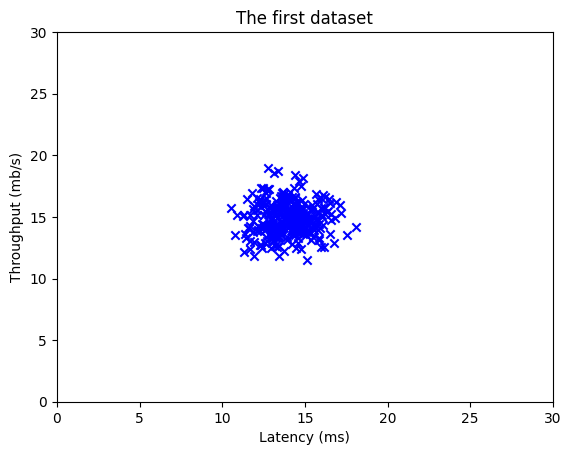

In [20]:
# Create a scatter plot of the data. To change the markers to blue "x",
# we used the 'marker' and 'c' parameters
plt.scatter(X_train[:, 0], X_train[:, 1], marker='x', c='b') 

# Set the title
plt.title("The first dataset")
# Set the y-axis label
plt.ylabel('Throughput (mb/s)')
# Set the x-axis label
plt.xlabel('Latency (ms)')
# Set axis range
plt.axis([0, 30, 0, 30])
plt.show()

In [21]:
def estimate_gaussian(X):
    m = len(X)
    mu = np.sum(X,axis=0)/ m
    var = np.sum((X-mu) ** 2, axis=0) / m
    return mu,var

In [22]:
# Estimate mean and variance of each feature
mu, var = estimate_gaussian(X_train)              

print("Mean of each feature:", mu)
print("Variance of each feature:", var)
    
# UNIT TEST
from public_tests2 import *
estimate_gaussian_test(estimate_gaussian)

Mean of each feature: [13.98140498 14.8656907 ]
Variance of each feature: [1.82083875 1.68191654]
Running estimate_gaussian_test...
All tests passed!


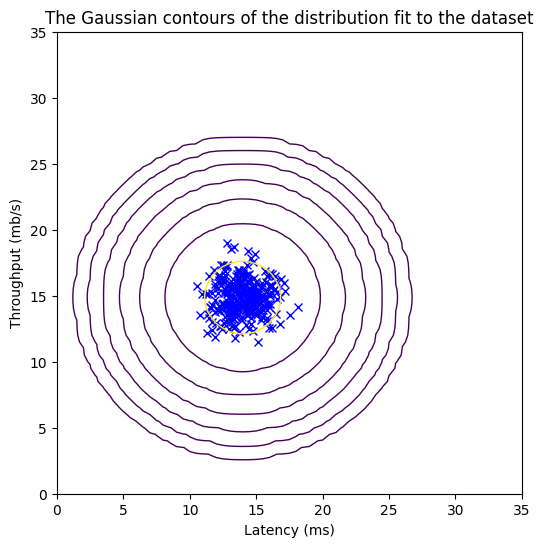

In [23]:
# Returns the density of the multivariate normal
# at each data point (row) of X_train
p = multivariate_gaussian(X_train, mu, var)

#Plotting code 
visualize_fit(X_train, mu, var)

In [24]:
def select_threshold(y_val,p_val):
    best_epsilon = 0
    best_F1 = 0
    F1 = 0
    
    step_size = (max(p_val) - min(p_val)) / 1000
    
    for epsilon in np.arange(min(p_val), max(p_val), step_size):
        
        predictions = (p_val < epsilon)
        
        fp = sum((predictions == 1) & (y_val == 0))
        tp = np.sum((predictions == 1) & (y_val == 1))
        fn = np.sum((predictions == 0) & (y_val == 1))
        
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        F1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon
    
    return best_epsilon,best_F1

In [25]:
p_val = multivariate_gaussian(X_val, mu, var)
epsilon, F1 = select_threshold(y_val, p_val)

print('Best epsilon found using cross-validation: %e' % epsilon)
print('Best F1 on Cross Validation Set: %f' % F1)
    
# UNIT TEST
select_threshold_test(select_threshold)

Best epsilon found using cross-validation: 9.078361e-05
Best F1 on Cross Validation Set: 1.000000
Running select_threshold_test...
All tests passed!


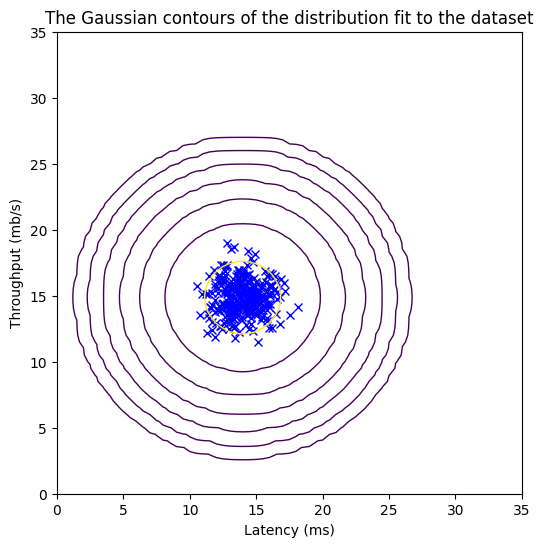

In [26]:
# Find the outliers in the training set 
outliers = p < epsilon

# Visualize the fit
visualize_fit(X_train, mu, var)

# Draw a red circle around those outliers
plt.plot(X_train[outliers, 0], X_train[outliers, 1], 'ro',
         markersize= 10,markerfacecolor='none', markeredgewidth=2)

In [29]:
print("训练集异常点数量:", np.sum(p < epsilon))
print("验证集预测异常数量:", np.sum(p_val < epsilon))


训练集异常点数量: 0
验证集预测异常数量: 20


In [30]:
pred_val = (p_val < epsilon)
print("验证集真实异常数:", np.sum(y_val == 1))
print("验证集检测出的异常数:", np.sum(pred_val == 1))
print("验证集检出的真实异常:", np.sum((pred_val == 1) & (y_val == 1)))


验证集真实异常数: 20
验证集检测出的异常数: 20
验证集检出的真实异常: 20


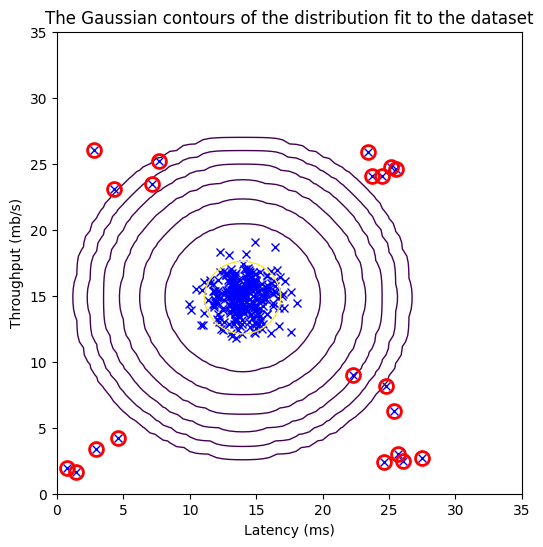

In [31]:
outliers_val = p_val < epsilon

visualize_fit(X_val, mu, var)
plt.plot(X_val[outliers_val, 0], X_val[outliers_val, 1], 'ro',
         markersize=10, markerfacecolor='none', markeredgewidth=2)
plt.show()
